# Testing code cleanup and translation to C++ with chatGPT

In [36]:
# setting up
import os
import subprocess
from more_itertools import strip
import numpy as np
import seaborn as sea
import matplotlib.pyplot as plt
import pandas as pd
import re
import random

# shortcuts
home = '~/research/nielsen_lab/phylogenetic-base-calling/'
sims_folder_paths = {'verr_lower':'step3_phylobc/sim_results_verr_lower/', 'verr':'step3_phylobc/sim_results_verr/', 'cerr':'step3_phylobc/sim_results_verr_compare/'}

In [37]:
# changing the script we're using
# phylobc_script = 'call_bases_from_pileup_pre_optimize.py'
phylobc_script = 'call_bases_from_pileup.py'

In [38]:
# getting the paths to specific pileup files from the simulations (variable error)
verr_subfolders = subprocess.run('ls ' + sims_folder_paths['verr'], shell=True, stdout=subprocess.PIPE).stdout.decode('utf-8')
verr_subfolders = verr_subfolders.strip().split('\n')
# same, lower variable error
verr_lower_subfolders = subprocess.run('ls ' + sims_folder_paths['verr_lower'], shell=True, stdout=subprocess.PIPE).stdout.decode('utf-8')
verr_lower_subfolders = verr_lower_subfolders.strip().split('\n')
# getting the paths to specific pileup files from the simulations (constant error)
cerr_subfolders = subprocess.run('ls ' + sims_folder_paths['cerr'], shell=True, stdout=subprocess.PIPE).stdout.decode('utf-8')
cerr_subfolders = cerr_subfolders.strip().split('\n')

subfolders = {'verr_lower':verr_lower_subfolders, 'verr':verr_subfolders, 'cerr':cerr_subfolders}

In [39]:
def get_cmd(subfolder, err_type): #err_type can be cerr, verr, verr_lower
    pileup_file = subfolder[12:] + '_sim_piledup.txt'
    pileup_results_path = sims_folder_paths[err_type] + subfolder + "/"
    return ' '.join(["./" + phylobc_script, pileup_file, pileup_results_path])

def run_accuracy_cmds(err_type):
    accuracy_cmd = open('get_accuracies_' + err_type +'.sh','w')
    accuracy_cmd.writelines('#!/bin/bash\n')
    run_script_cmds = [get_cmd(sf, err_type) for sf in subfolders[err_type]]
    accuracy_cmd.writelines(' & \n'.join(run_script_cmds))
    accuracy_cmd.close()
    subprocess.run('chmod +x get_accuracies_' + err_type + '.sh', shell=True)
    subprocess.run('{ time ./get_accuracies_' + err_type + '.sh >> accuracies_' + err_type + '.txt ; } 2> accuracies_' + err_type + '_time.txt', shell=True)

In [40]:
# running accuracy in the constant error simulations (at 0.5% -- i.e. ~150 bp will be wrong)
run_accuracy_cmds('cerr')
# running accuracy in the variable error simulations
run_accuracy_cmds('verr')
# running accuracy in the LOWER variable error simulations
run_accuracy_cmds('verr_lower')

In [42]:
title_abbrev = {'cerr':'constant 0.5% error', 'verr':'higher variable error', 'verr_lower':'lower variable error'}
def reshape_plot_accuracies(err_type):
    accuracy = pd.read_csv('accuracies_' + err_type + '.txt', header=None)
    accuracy.columns = ['file','prior','posterior','likelihood']
    accuracy['depth'] = [float(re.split('x_',f)[0]) for f in accuracy['file']]
    accuracy_long = pd.melt(accuracy, id_vars=['file','depth'], value_vars=['prior','posterior','likelihood'], var_name='calculation_type',value_name='accuracy')
    accuracy_long['n_wrong_bases'] = [int(b) for b in (30000*(1 - accuracy_long['accuracy']))]
    ax = sea.barplot(data = accuracy_long, x = 'depth', y = 'accuracy', hue = 'calculation_type')
    ax.set_title('Base calling on simulated reads (' + title_abbrev[err_type] + ')')
    return ax

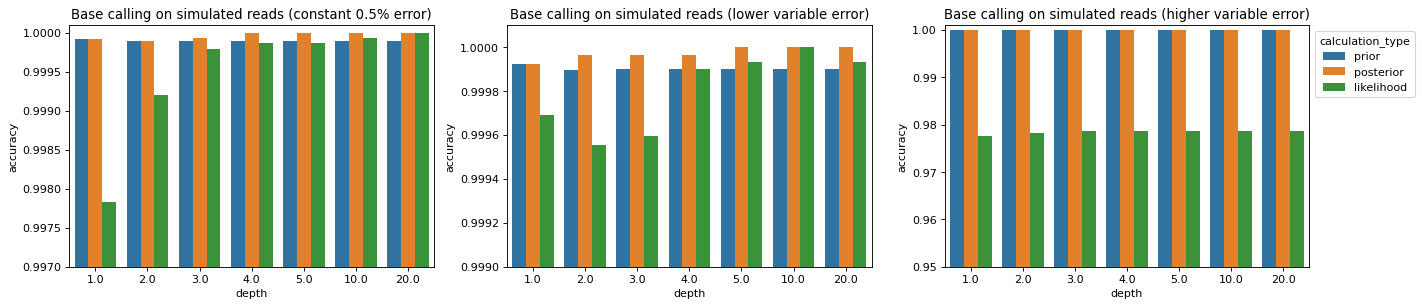

In [43]:
fig = plt.figure(figsize=(20, 4), dpi=80)

plt.subplot(1, 3, 1)
ax_cerr = reshape_plot_accuracies('cerr')
ax_cerr.set_ylim([0.997,1.0001])
ax_cerr.get_legend().remove()

plt.subplot(1, 3, 2)
ax_lower_verr = reshape_plot_accuracies('verr_lower')
ax_lower_verr.set_ylim([0.999,1.0001])
ax_lower_verr.get_legend().remove()

plt.subplot(1, 3, 3)
ax_verr = reshape_plot_accuracies('verr')
ax_verr.set_ylim([0.95,1.001])
sea.move_legend(ax_verr, "upper left", bbox_to_anchor=(1, 1))
plt.show()